# Trabalhando com imagens de rótulos

Uma imagem de rótulos representa objetos relevantes presentes em uma imagem, representados poe componentes conexos possuindo o mesmo valor.

'Imagem original'

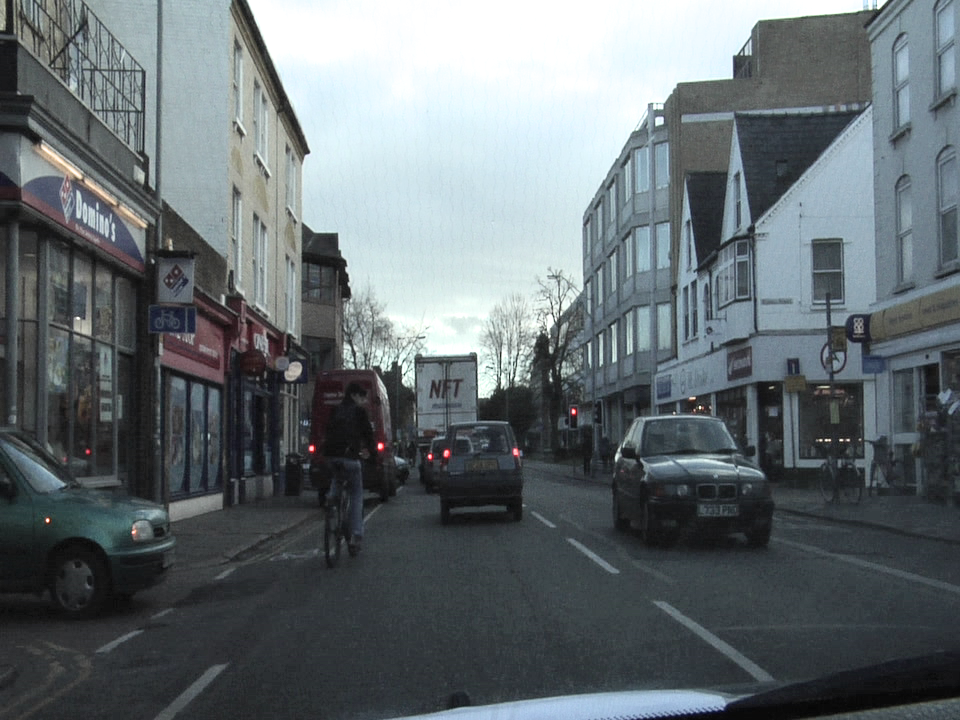

'Imagem de rótulos'

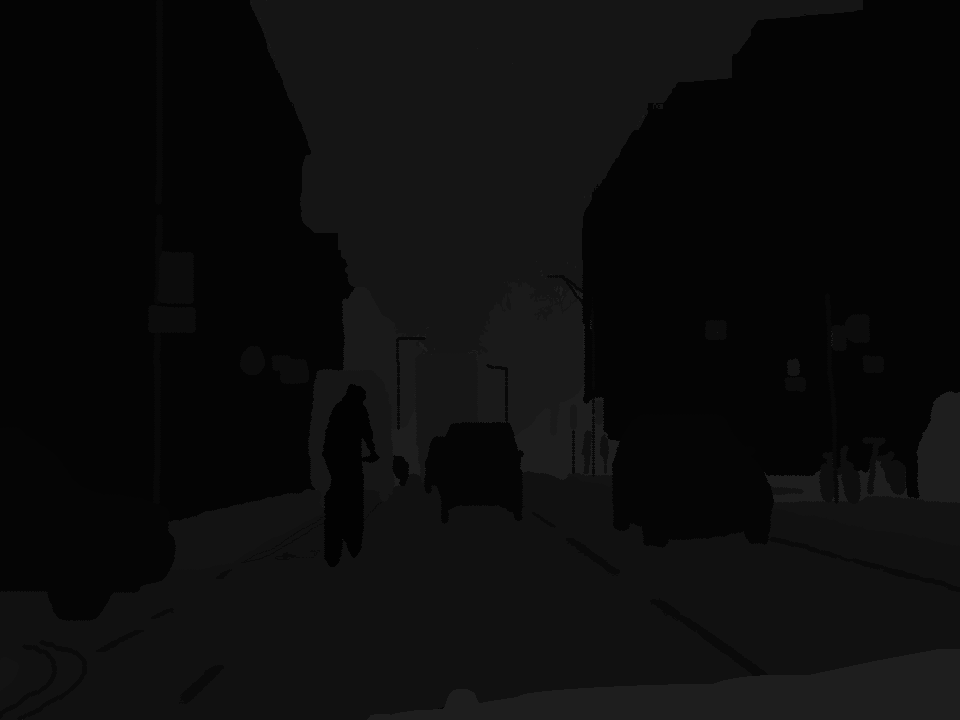

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

img = Image.open("../../dados/street.png")
labels = Image.open("../../dados/street_labels.png")
display("Imagem original", img, "Imagem de rótulos", labels)

In [2]:
# Visualização dos valores únicos
labels_np = np.array(labels)
classes = np.unique(labels_np)
print(classes)

[ 2  4  5  8 10 12 14 16 17 19 20 21 22 24 26 30]


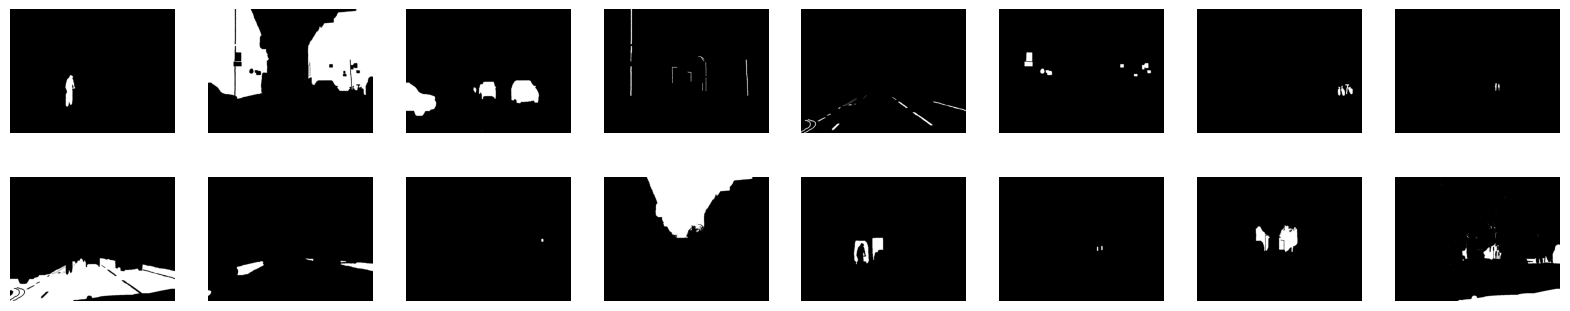

In [3]:
# Visualização de cada classe

fig, axs = plt.subplots(2, 8, figsize=(20, 4))
axs = axs.flatten()
for c, ax in zip(classes, axs):
    labels_class = labels_np==c
    ax.imshow(labels_class, "gray")
    ax.set_axis_off()

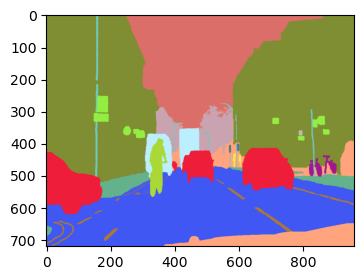

In [4]:
# Criação de uma imagem colorida contendo cores para cada classe
colors = [np.random.randint(0, 256, 3) for _ in classes]

img_color = np.zeros((labels_np.shape[0], labels_np.shape[1], 3), dtype=np.uint8)
for c_ind, color in enumerate(classes):
    ind = np.nonzero(labels_np==color)
    img_color[ind[0], ind[1]] = colors[c_ind]
    
plt.imshow(img_color)

Podemos unir a imagem original e a imagem de rótulos utilizando uma técnica chamada de *alpha blending*, que nada mais é do que somar as duas imagens multiplicadas por coeficientes entre 0 e 1.

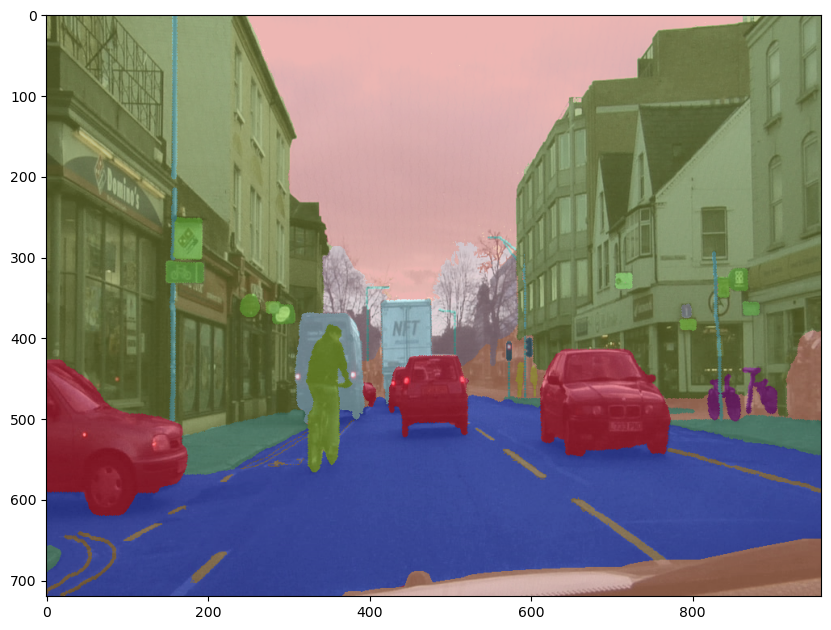

In [5]:
alpha = 0.5

img_np = np.array(img)

img_blend = alpha*img_color + (1-alpha)*img_np
img_blend = img_blend.astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(img_blend)

### Redimensionando uma imagem binária

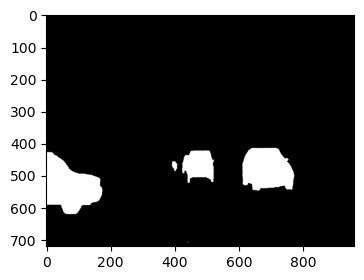

In [6]:
img_bin = labels_np==5
plt.imshow(img_bin, "gray")

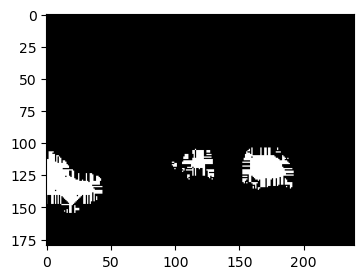

In [7]:
from scipy.ndimage import zoom

# A função zoom do scipy pode ser utilizada para redimensionar uma imagem. Mas ela utiliza interpolação
# para fazer o redimensionamento.
img_out = zoom(img_bin, 0.25)
plt.figure()
plt.imshow(img_out, "gray")

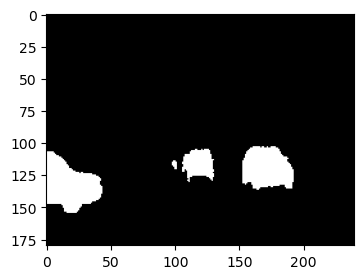

In [8]:
# O correto é utilizar ordem 0, que não realizar interpolação.
img_out = zoom(img_bin, 0.25, order=0)
plt.figure()
plt.imshow(img_out, "gray")